# 🛰️ Field Boundary Delineation with SAM — Streamlit Dashboard
### Test AOI: Bangladesh farmland (Bhola / Barisal delta) — `22.3145325, 90.1558515`

**Pipeline**
1. **AOI** — user **draws** an area of interest directly on the satellite map
2. **Imagery** — download Google (or Esri) satellite tiles → georeferenced GeoTIFF
3. **Segment** — Segment Anything (SAM 2) automatic mask generation
4. **Vectorize** — masks → polygons → **boundary lines**, plotted on a satellite map

This notebook contains **all the code**: the step-by-step pipeline *and* the full
Streamlit app (written out via `%%writefile app.py`).

---
> **Where to run this**
> The heavy steps (tile download + SAM inference) need (a) internet access to Google/Esri
> tile servers and Meta's SAM 2 weight hosts, and (b) ideally a **GPU**. Run this in
> **Google Colab (GPU runtime)** or a local CUDA machine.
> `Runtime → Change runtime type → GPU`.
>
> **Note on Bangladesh:** this AOI is smallholder deltaic farmland — small (<0.1 ha),
> fragmented, irregular parcels. This is the *hard* case for SAM: automatic mode tends to
> over-segment heterogeneous canopy and merge same-tone neighbours. The post-processing
> and tuning knobs below matter here; expect to iterate, and treat SAM output as a
> first draft to clean, not a finished cadastre.


## 0 · Install dependencies
Run once. `segment-geospatial` pulls in `torch`, `sam2`, and the geospatial stack.

**Local Linux note:** do **not** `pip install gdal` unbounded. PyPI’s latest `GDAL` is a source tarball (e.g. 3.13.2) that will not build against Ubuntu’s `libgdal` (often 3.8.x). Rasterio wheels already bundle GDAL; if Python `osgeo` bindings are needed they must match `gdal-config --version`.

In [2]:
# Pin Python GDAL bindings to the *system* libgdal so pip never tries GDAL 3.13.x
# from source ("require at least libgdal 3.13.2, but 3.8.4 was found").
# Rasterio / pyogrio wheels already ship GDAL — the `gdal` PyPI package is optional.
import os, shutil, subprocess, sys, tempfile

cmd = [
    sys.executable, "-m", "pip", "install", "-q",
    "segment-geospatial", "leafmap", "streamlit", "streamlit-folium",
    "geopandas", "rasterio", "shapely",
]
if shutil.which("gdal-config"):
    ver = subprocess.check_output(["gdal-config", "--version"], text=True).strip()
    cf = os.path.join(tempfile.gettempdir(), "gdal-constraints.txt")
    with open(cf, "w") as f:
        f.write(f"gdal=={ver}\nGDAL=={ver}\n")
    cmd[4:4] = ["-c", cf]  # insert after "install" "-q"
    print(f"Constraining pip GDAL == {ver} (system libgdal)")
else:
    print("No gdal-config — skipping GDAL pin (Colab/conda usually already match)")

subprocess.check_call(cmd)
print("Install OK")
# (samgeo == segment-geospatial). For SAM v1 / HQ-SAM instead of SAM 2, it's included too.

Note: you may need to restart the kernel to use updated packages.


In [1]:
import os, tempfile
import numpy as np
import geopandas as gpd
# Heavy geospatial+SAM imports are done inside the step cells so this notebook
# stays importable even without a GPU.

# Default test field (Bhola / Barisal). Used whenever no shape is drawn.
CENTER_LAT, CENTER_LON, ZOOM = 22.3145325, 90.1558515, 18

def default_bbox(lat=CENTER_LAT, lon=CENTER_LON, half_m=400.0):
    """~800 m box around a lon/lat point → [minx, miny, maxx, maxy]."""
    dlat = half_m / 110_900.0
    dlon = half_m / (111_320.0 * np.cos(np.radians(lat)))
    return [lon - dlon, lat - dlat, lon + dlon, lat + dlat]

bbox = default_bbox()  # always defined; capture cell overrides if a shape is drawn

## 1 · Draw the Area of Interest (AOI) interactively
The map opens over the Bangladesh test field (`22.3145325, 90.1558515`); pan/zoom to your
field, then use the **rectangle or polygon draw tool** (toolbar, left edge) to outline it.

If nothing is drawn — or the widget never reports the shape back (common in VS Code / Cursor) —
the capture cell falls back to an ~800 m box around that test point so later steps can still run.

In [12]:
# Map starts over the Bangladesh test field. Drawing is optional — bbox already
# has a default from the imports cell.
try:
    import leafmap
    m = leafmap.Map(center=[CENTER_LAT, CENTER_LON], zoom=ZOOM)
    m.add_basemap("SATELLITE")     # Google satellite XYZ tiles
    display(m)                     # optional: draw a rectangle/polygon (toolbar, left)
except Exception as e:
    m = None
    print("[interactive map needs leafmap + a live Jupyter kernel]")
    print("  reason:", type(e).__name__, "-", str(e)[:100])

Map(center=[22.3145325, 90.1558515], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title…

### Capture the drawn AOI
After drawing, run the next cell — it reads the drawn shape as
`bbox = [minx, miny, maxx, maxy]`. If no shape is captured, it uses the default
Bangladesh test bbox instead of blocking the rest of the pipeline.

In [13]:
# Optional: draw a rectangle/polygon on the map above, then re-run this cell.
# In VS Code / Cursor the widget often does not report the shape — that's fine;
# bbox is already set to the default Bangladesh test box from the imports cell.

drawn = None
if m is not None:
    try:
        drawn = m.user_roi_bounds()
    except Exception:
        drawn = None
    if not drawn:
        roi = getattr(m, "user_roi", None) or getattr(m, "user_rois", None)
        if isinstance(roi, dict):
            geoms = []
            if roi.get("type") == "FeatureCollection":
                geoms = [f.get("geometry") for f in roi.get("features", [])]
            else:
                geoms = [roi.get("geometry", roi)]
            xs, ys = [], []
            def _walk(c):
                if isinstance(c, (list, tuple)) and c and isinstance(c[0], (int, float)):
                    xs.append(c[0]); ys.append(c[1])
                elif isinstance(c, (list, tuple)):
                    for item in c:
                        _walk(item)
            for g in geoms:
                if g:
                    _walk(g.get("coordinates"))
            if xs:
                drawn = [min(xs), min(ys), max(xs), max(ys)]

if drawn:
    bbox = drawn
    print("AOI bbox from drawn shape.")
else:
    bbox = default_bbox()
    print("No drawn AOI captured — using default ~800 m Bangladesh test bbox.")
    print("  (Draw on the map above and re-run this cell to override.)")
print("AOI bbox (minx, miny, maxx, maxy):", [round(v, 6) for v in bbox])

To proceed, please draw an AOI on the map above (rectangle or polygon), then re-run this cell.
(If you see this in a static/non-interactive environment, drawing may not be available.)


## 2 · Download satellite tiles → georeferenced GeoTIFF
Mosaic XYZ tiles covering the bbox and write a GeoTIFF (EPSG:3857) with **rasterio**
(avoids `osgeo._gdal_array`, which is often missing when pip-built GDAL was compiled
without numpy).

**Imagery source note:** `"SATELLITE"` uses Google tiles — fine for prototyping, but
reprocessing/redistributing them sits uneasily with the Google Maps ToS. For Bangladesh
(NAIP is US-only), **Esri World Imagery** is a ToS-friendlier high-res option.

In [21]:
# Do NOT pip-install unbounded `gdal` / `GDAL`. The PyPI sdist builds without
# `_gdal_array`, which is exactly what samgeo.tms_to_geotiff.WriteArray needs.
# The next cell mosaics tiles and writes the GeoTIFF with rasterio instead.
print("Skipping osgeo.gdal — GeoTIFF write uses rasterio (bundled GDAL).")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 802.5/802.5 kB 10.5 MB/s  0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for GDAL: filename=gdal-3.8.4-cp311-cp311-linux_x86_64.whl size=4670360 sha256=1684807ad390ebf9e09da7cd2f7c383b5aa759a30d295df78a3ff9a1deaef0f7
  Stored in directory: /home/zia207/.cache/pip/wheels/06/a9/71/7b1ee8186f3a317cd34c6f7a7dd8627fa28b61e6c63e039f9d
Successfully built GDAL
Note: you may need to restart the kernel to use updated packages.


In [23]:
import math
from concurrent.futures import ThreadPoolExecutor, as_completed
from io import BytesIO
from urllib.request import Request, urlopen

from PIL import Image
import rasterio
from rasterio.transform import from_bounds
from rasterio.windows import Window, from_bounds as window_from_bounds

ESRI = ("https://server.arcgisonline.com/ArcGIS/rest/services/"
        "World_Imagery/MapServer/tile/{z}/{y}/{x}")
GOOGLE = "https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}"
image_tif = "bangladesh_aoi.tif"

_ORIGIN = 20037508.342789244
_R = 6378137.0
_TILE = 256


def _lonlat_to_3857(lon, lat):
    lat = max(min(float(lat), 85.05112878), -85.05112878)
    x = _R * math.radians(float(lon))
    y = _R * math.log(math.tan(math.pi / 4 + math.radians(lat) / 2))
    return x, y


def _lonlat_to_tile(lon, lat, z):
    lat = max(min(float(lat), 85.05112878), -85.05112878)
    n = 2 ** z
    x = (float(lon) + 180.0) / 360.0 * n
    y = (1.0 - math.asinh(math.tan(math.radians(lat))) / math.pi) / 2.0 * n
    return x, y


def tiles_to_geotiff(output, bbox, zoom=18, source="SATELLITE", overwrite=True):
    """Download XYZ tiles and write a georeferenced GeoTIFF via rasterio (no osgeo)."""
    if (not overwrite) and os.path.exists(output):
        print(f"{output} exists — skip (overwrite=True to replace)")
        return
    bbox = [float(v) for v in bbox]
    minx, miny, maxx, maxy = bbox
    url = GOOGLE if source == "SATELLITE" else (source if str(source).startswith("http") else ESRI)

    tx0, ty_n = _lonlat_to_tile(minx, maxy, zoom)
    tx1, ty_s = _lonlat_to_tile(maxx, miny, zoom)
    xmin, xmax = int(math.floor(tx0)), int(math.floor(tx1))
    ymin, ymax = int(math.floor(ty_n)), int(math.floor(ty_s))

    n = 2 ** zoom
    tile_m = 2 * _ORIGIN / n
    west  = -_ORIGIN + xmin * tile_m
    east  = -_ORIGIN + (xmax + 1) * tile_m
    north =  _ORIGIN - ymin * tile_m
    south =  _ORIGIN - (ymax + 1) * tile_m

    w = (xmax - xmin + 1) * _TILE
    h = (ymax - ymin + 1) * _TILE
    mosaic = np.zeros((h, w, 3), dtype=np.uint8)
    jobs = [(x, y) for y in range(ymin, ymax + 1) for x in range(xmin, xmax + 1)]
    ua = {"User-Agent": "field-boundaries/1.0"}

    def _fetch(x, y):
        req = Request(url.format(z=zoom, x=x, y=y), headers=ua)
        with urlopen(req, timeout=30) as r:
            arr = np.asarray(Image.open(BytesIO(r.read())).convert("RGB"))
        return x, y, arr

    done = 0
    with ThreadPoolExecutor(max_workers=8) as pool:
        futs = [pool.submit(_fetch, x, y) for x, y in jobs]
        for fut in as_completed(futs):
            x, y, arr = fut.result()
            mosaic[(y - ymin) * _TILE:(y - ymin + 1) * _TILE,
                   (x - xmin) * _TILE:(x - xmin + 1) * _TILE] = arr
            done += 1
            print(f"Downloaded image {done:02d}/{len(jobs)}")

    transform = from_bounds(west, south, east, north, w, h)
    ax0, ay0 = _lonlat_to_3857(minx, miny)
    ax1, ay1 = _lonlat_to_3857(maxx, maxy)
    win = window_from_bounds(min(ax0, ax1), min(ay0, ay1),
                             max(ax0, ax1), max(ay0, ay1), transform)
    win = win.round_offsets().round_lengths()
    row, col = max(0, int(win.row_off)), max(0, int(win.col_off))
    height = min(int(win.height), h - row)
    width  = min(int(win.width),  w - col)
    crop = mosaic[row:row + height, col:col + width]
    crop_tf = rasterio.windows.transform(Window(col, row, width, height), transform)

    profile = dict(driver="GTiff", height=height, width=width, count=3, dtype="uint8",
                   crs="EPSG:3857", transform=crop_tf, compress="lzw", tiled=True)
    with rasterio.open(output, "w", **profile) as dst:
        for i in range(3):
            dst.write(crop[:, :, i], i + 1)


_lat = globals().get("CENTER_LAT", 22.3145325)
_lon = globals().get("CENTER_LON", 90.1558515)
_zoom = int(globals().get("ZOOM", 18))
if "bbox" not in globals() or not bbox:
    _dlat = 400.0 / 110_900.0
    _dlon = 400.0 / (111_320.0 * np.cos(np.radians(_lat)))
    bbox = [_lon - _dlon, _lat - _dlat, _lon + _dlon, _lat + _dlat]
bbox = [float(v) for v in bbox]
print("Downloading tiles for bbox:", [round(v, 6) for v in bbox])

try:
    tiles_to_geotiff(image_tif, bbox, zoom=_zoom, source="SATELLITE", overwrite=True)
    # or: tiles_to_geotiff(image_tif, bbox, zoom=_zoom, source=ESRI, overwrite=True)
    print("Saved:", image_tif)
except Exception as e:
    print("[skipped — tile download / GeoTIFF write failed]")
    print("  reason:", type(e).__name__, "-", str(e)[:300])

Downloaded image 01/42
Downloaded image 02/42
Downloaded image 03/42
Downloaded image 04/42
Downloaded image 05/42
Downloaded image 06/42
Downloaded image 07/42
Downloaded image 08/42
Downloaded image 09/42
Downloaded image 10/42
Downloaded image 11/42
Downloaded image 12/42
Downloaded image 13/42
Downloaded image 14/42
Downloaded image 15/42
Downloaded image 16/42
Downloaded image 17/42
Downloaded image 18/42
Downloaded image 19/42
Downloaded image 20/42
Downloaded image 21/42
Downloaded image 22/42
Downloaded image 23/42
Downloaded image 24/42
Downloaded image 25/42
Downloaded image 26/42
Downloaded image 27/42
Downloaded image 28/42
Downloaded image 29/42
Downloaded image 30/42
Downloaded image 31/42
Downloaded image 32/42
Downloaded image 33/42
Downloaded image 34/42
Downloaded image 35/42
Downloaded image 36/42
Downloaded image 37/42
Downloaded image 38/42
Downloaded image 39/42
Downloaded image 40/42
Downloaded image 41/42
Downloaded image 42/42
Saved: bangladesh_aoi.tif


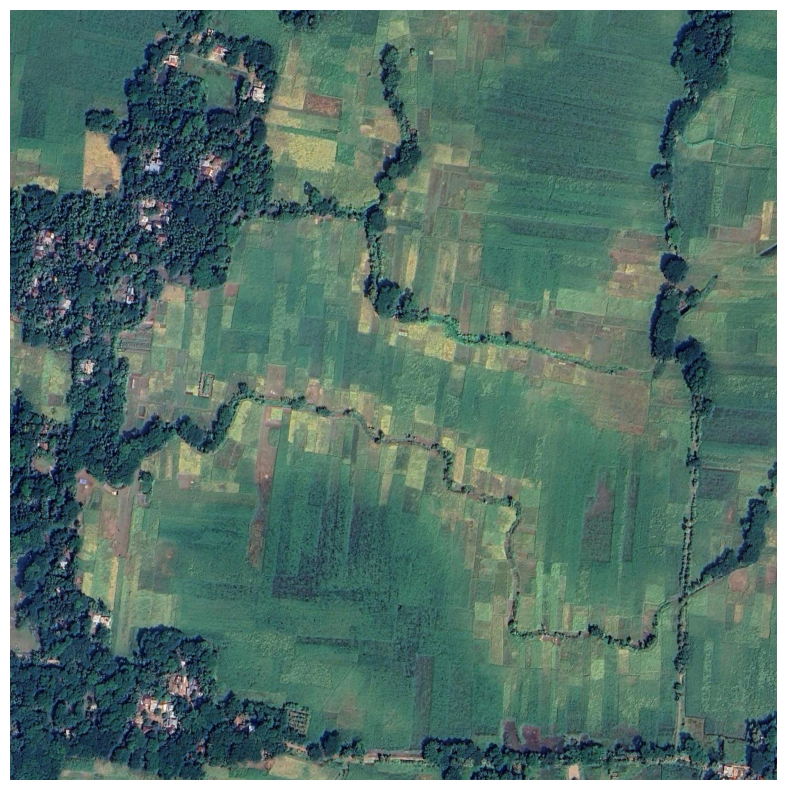

In [24]:
## Plotting the image
import matplotlib.pyplot as plt
import rasterio

# Load the GeoTIFF image
image_tif = "bangladesh_aoi.tif"
try:
    with rasterio.open(image_tif) as src:
        image = src.read()
        # Reorder from (bands, height, width) to (height, width, bands)
        if image.shape[0] >= 3:
            image_rgb = image[:3].transpose(1, 2, 0)
        else:
            # For single-band images (grayscale), repeat channel
            image_rgb = np.repeat(image[0][..., np.newaxis], 3, axis=2)

    # Display the image
    plt.figure(figsize=(10, 10))
    plt.imshow(image_rgb)
    plt.axis('off')
except Exception as e:
    print("[skipped — could not plot GeoTIFF image]")
    print("  reason:", type(e).__name__, "-", str(e)[:200])

## 3 · Segment with SAM 2 (automatic mask generation)
Auto mode segments every object it finds. For **smallholder fields**, push segmentation finer
(`points_per_side`↑) and filter later. Tuning kwargs are passed where the installed
`samgeo` version supports them; otherwise it falls back to defaults.

In [ ]:
%pip install segment-geospatial[samgeo2]

In [25]:
mask_tif = "bangladesh_mask.tif"

try:
    from samgeo import SamGeo2
    try:
        sam = SamGeo2(
            model_id="sam2-hiera-large",   # -small / -tiny are lighter & faster
            automatic=True,
            points_per_side=32,            # ↑ (48-64) for small fragmented fields
            pred_iou_thresh=0.86,
            stability_score_thresh=0.90,
            min_mask_region_area=100,
        )
    except TypeError:
        sam = SamGeo2(model_id="sam2-hiera-large", automatic=True)
    sam.generate(image_tif, output=mask_tif)
    print("Saved mask:", mask_tif)
    # Text-prompted alternative: sam.predict(image_tif, "farmland field")
except Exception as e:
    print("[skipped here — SAM 2 needs its weights (download) and a GPU; run on Colab/GPU]")
    print("  reason:", type(e).__name__, "-", str(e)[:100])

[skipped here — SAM 2 needs its weights (download) and a GPU; run on Colab/GPU]
  reason: ImportError - To use SamGeo 2, install it as:
	pip install segment-geospatial[samgeo2]


## 4 · Vectorize → polygons → **boundary lines** (with post-processing)
`raster_to_vector` turns the mask into polygons; then we drop slivers, simplify, and convert
each polygon to its boundary `LineString`. *(This is the exact logic validated offline below.)*

In [ ]:
import os
polygons = lines = None
try:
    from samgeo.common import raster_to_vector
    if not os.path.exists(mask_tif):
        raise FileNotFoundError("mask not produced in this environment")
    raw_geojson = "fields_raw.geojson"
    raster_to_vector(mask_tif, raw_geojson)          # polygons (georeferenced)

    gdf = gpd.read_file(raw_geojson)
    gm  = gdf.to_crs(3857)
    gm["area_ha"] = gm.area / 1e4
    gm = gm[gm["area_ha"] >= 0.02]                    # min-area filter
    gm["geometry"] = gm.simplify(2.0)                 # Douglas-Peucker (m)

    polygons = gm.to_crs(4326)
    lines = gm.copy(); lines["geometry"] = lines.boundary   # POLYGON -> LINESTRING
    lines = lines.to_crs(4326)
    polygons.to_file("field_polygons.geojson", driver="GeoJSON")
    lines.to_file("field_boundaries_lines.geojson", driver="GeoJSON")
    print(f"{len(polygons)} fields -> {len(lines)} boundary lines")
except Exception as e:
    print("[skipped here — depends on the SAM mask above; run on Colab/GPU]")
    print("  reason:", type(e).__name__, "-", str(e)[:100])
    print("  (the offline validation cell below runs the identical vector logic for real)")

## 5 · Plot boundaries on a satellite basemap
Overlay the vector lines on the Google/Esri satellite basemap. To render on the **Google Maps
JS API** instead, export the GeoJSON and load it client-side with `map.data.loadGeoJson()`.

In [ ]:
try:
    import leafmap
    if lines is None:
        raise RuntimeError("no boundaries in this environment")
    r = leafmap.Map(center=[CENTER_LAT, CENTER_LON], zoom=ZOOM)
    r.add_basemap("SATELLITE")
    r.add_gdf(lines, layer_name="Field boundaries",
              style={"color": "#ff2b2b", "weight": 2, "fillOpacity": 0})
    display(r)
except Exception as e:
    print("[skipped here — needs the boundaries + basemap tiles; run on Colab/GPU]")
    print("  reason:", type(e).__name__, "-", str(e)[:100])

---
## ✅ Offline validation of Step 4 (run in this notebook, no GPU/network needed)
This reproduces the vectorize → boundary-line logic on a **synthetic** parcel mask
georeferenced to the Bangladesh AOI. It confirms the geometry pipeline is correct
independent of the tile download and SAM inference.

In [ ]:
%matplotlib inline
import numpy as np, rasterio
from rasterio.transform import from_bounds
from rasterio import features
import geopandas as gpd
from shapely.geometry import shape
import matplotlib.pyplot as plt

clat, clon, half_m = 22.3145325, 90.1558515, 400.0
dlat = half_m/110900.0; dlon = half_m/(111320.0*np.cos(np.radians(clat)))
minx, miny, maxx, maxy = clon-dlon, clat-dlat, clon+dlon, clat+dlat
H = W = 512
transform = from_bounds(minx, miny, maxx, maxy, W, H)

# synthetic fragmented parcels (nearest-seed / Voronoi-like) as a stand-in mask
rng = np.random.default_rng(7); n = 40
sy, sx = rng.integers(0, H, n), rng.integers(0, W, n)
yy, xx = np.mgrid[0:H, 0:W]
d = (yy[...,None]-sy[None,None,:])**2 + (xx[...,None]-sx[None,None,:])**2
labels = (np.argmin(d, axis=2)+1).astype(np.int32)

polys, vals = [], []
for geom, val in features.shapes(labels, transform=transform):
    polys.append(shape(geom)); vals.append(val)
gdf = gpd.GeoDataFrame({"value": vals}, geometry=polys, crs="EPSG:4326")

gm = gdf.to_crs(3857); gm["area_ha"] = gm.area/1e4
gm = gm[gm.area_ha >= 0.02]; gm["geometry"] = gm.simplify(2.0)
lines = gm.copy(); lines["geometry"] = lines.boundary; lines = lines.to_crs(4326)
print(f"parcels={len(gdf)}  fields={len(gm)}  boundary lines={len(lines)}  "
      f"types={sorted(lines.geom_type.unique())}")

fig, ax = plt.subplots(1, 2, figsize=(11, 5))
gdf.plot(ax=ax[0], column="value", cmap="tab20", edgecolor="k", linewidth=0.3)
ax[0].set_title(f"Vectorized parcels (n={len(gdf)})"); ax[0].axis("off")
lines.plot(ax=ax[1], color="crimson", linewidth=1.1)
ax[1].set_title(f"Boundary LINES (n={len(lines)})"); ax[1].axis("off")
plt.tight_layout(); plt.show()

---
## 🚀 The Streamlit dashboard
Running the next cell writes **`app.py`**. Launch it with:

```bash
streamlit run app.py
```

The app: pick/draw AOI → choose imagery + SAM model → run → view boundary lines on a
satellite map → download GeoJSON.

In [ ]:
%%writefile app.py
# app.py — Field Boundary Delineation Dashboard (SAM 2) — Streamlit — draw-only AOI
import os, tempfile
import numpy as np
import streamlit as st

st.set_page_config(page_title="Field Boundary Delineation (SAM)", layout="wide")
st.title("🛰️ Field Boundary Delineation with SAM")
st.caption("Draw an AOI → satellite tiles → Segment Anything (SAM 2) → vector field boundaries")

import leafmap.foliumap as leafmap
from streamlit_folium import st_folium
import geopandas as gpd

ESRI = ("https://server.arcgisonline.com/ArcGIS/rest/services/"
        "World_Imagery/MapServer/tile/{z}/{y}/{x}")
SOURCES = {"SATELLITE (Google)": "SATELLITE", "Esri World Imagery": ESRI}

# Initial map view (Bangladesh test field). The AOI itself is whatever the user DRAWS.
START_LAT, START_LON = 22.3145325, 90.1558515

@st.cache_resource(show_spinner=False)
def load_sam(model_id, pps, iou):
    from samgeo import SamGeo2
    try:
        return SamGeo2(model_id=model_id, automatic=True,
                       points_per_side=pps, pred_iou_thresh=iou)
    except TypeError:
        return SamGeo2(model_id=model_id, automatic=True)

# ---------------- sidebar ----------------
with st.sidebar:
    st.header("1 · Imagery")
    source = st.selectbox("Tile source", list(SOURCES))
    zoom = st.slider("Zoom (tile)", 16, 20, 18)

    st.header("2 · SAM")
    model_id = st.selectbox("Model", ["sam2-hiera-large", "sam2-hiera-small", "sam2-hiera-tiny"])
    pps = st.slider("points_per_side", 16, 64, 32, 8)
    iou = st.slider("pred_iou_thresh", 0.50, 0.95, 0.86, 0.01)

    st.header("3 · Post-process")
    min_ha = st.number_input("Min field area (ha)", 0.0, 5.0, 0.02, 0.01)
    simp   = st.number_input("Simplify (m)", 0.0, 20.0, 2.0, 0.5)

    run = st.button("Run segmentation", type="primary", use_container_width=True)

# ---------------- draw the AOI ----------------
left, right = st.columns(2)
with left:
    st.subheader("Draw AOI")
    st.caption("Use the rectangle/polygon tool on the map, then click **Run segmentation**.")
    m = leafmap.Map(center=[START_LAT, START_LON], zoom=zoom, draw_control=True)
    m.add_basemap("SATELLITE")
    drawn = st_folium(m, height=480, returned_objects=["last_active_drawing"])

bbox = None
if drawn and drawn.get("last_active_drawing"):
    coords = drawn["last_active_drawing"]["geometry"]["coordinates"][0]
    xs = [c[0] for c in coords]; ys = [c[1] for c in coords]
    bbox = [min(xs), min(ys), max(xs), max(ys)]

# ---------------- pipeline ----------------
if run:
    if bbox is None:
        st.warning("Draw an AOI on the map first (rectangle or polygon), then run again.")
    else:
        tmp = tempfile.gettempdir()
        try:
            with st.spinner("Downloading satellite tiles…"):
                from samgeo.common import tms_to_geotiff, raster_to_vector
                image_tif = os.path.join(tmp, "aoi.tif")
                tms_to_geotiff(output=image_tif, bbox=bbox, zoom=zoom,
                               source=SOURCES[source], overwrite=True)

            with st.spinner("Running SAM 2 (first run downloads weights; GPU strongly advised)…"):
                sam = load_sam(model_id, pps, iou)
                mask_tif = os.path.join(tmp, "mask.tif")
                sam.generate(image_tif, output=mask_tif)

            with st.spinner("Vectorizing → boundary lines…"):
                raw = os.path.join(tmp, "fields_raw.geojson")
                raster_to_vector(mask_tif, raw)
                gm = gpd.read_file(raw).to_crs(3857)
                gm["area_ha"] = gm.area / 1e4
                gm = gm[gm["area_ha"] >= min_ha]
                if simp > 0:
                    gm["geometry"] = gm.simplify(simp)
                lines = gm.copy(); lines["geometry"] = lines.boundary
                cy = (bbox[1] + bbox[3]) / 2; cx = (bbox[0] + bbox[2]) / 2
                st.session_state["lines"] = lines.to_crs(4326)
                st.session_state["polys"] = gm.to_crs(4326)
                st.session_state["ctr"] = [cy, cx]; st.session_state["z"] = zoom
        except Exception as e:
            st.error(f"Pipeline failed: {e}")

# ---------------- result ----------------
with right:
    st.subheader("Result")
    if "lines" in st.session_state:
        lines = st.session_state["lines"]; polys = st.session_state["polys"]
        r = leafmap.Map(center=st.session_state["ctr"], zoom=st.session_state["z"])
        r.add_basemap("SATELLITE")
        r.add_gdf(lines, layer_name="Boundaries",
                  style={"color": "#ff2b2b", "weight": 2, "fillOpacity": 0})
        st_folium(r, height=480)
        st.success(f"{len(lines)} field boundaries delineated")
        c1, c2 = st.columns(2)
        c1.download_button("⬇ boundaries (GeoJSON)", lines.to_json(),
                           "field_boundaries.geojson", use_container_width=True)
        c2.download_button("⬇ polygons (GeoJSON)", polys.to_json(),
                           "field_polygons.geojson", use_container_width=True)
    else:
        st.info("Draw an AOI and click **Run segmentation**.")

with st.expander("⚠️ Notes & caveats"):
    st.markdown(
        "- **GPU:** SAM 2 is heavy — CPU inference is minutes per tile. Use a GPU backend; "
        "Streamlit Community Cloud has no GPU.\n"
        "- **Imagery ToS:** Google satellite tiles are for prototyping; prefer **Esri World "
        "Imagery** for Bangladesh, or a licensed source, for anything you redistribute.\n"
        "- **Smallholder fields:** auto-SAM over/under-segments small fragmented parcels — "
        "tune `points_per_side` and the area filter, and treat output as a first draft.")


### Run instructions & production notes
- **Launch:** `streamlit run app.py` (from a GPU-enabled environment).
- **GPU:** wrap the model load in `st.cache_resource` (done) so weights load once. On
  Streamlit Community Cloud (no GPU) inference is impractical — deploy on a GPU VM, a
  FastAPI inference microservice, or Hugging Face Spaces with a GPU.
- **Imagery licensing:** Google tiles → prototyping only. For Bangladesh, prefer **Esri World
  Imagery** (selectable in the app) or a licensed feed. NAIP is US-only.
- **Quality on smallholder fields:** if raw SAM over/under-segments, consider (a) higher
  `points_per_side`, (b) seasonal false-colour composites (better parcel contrast), or
  (c) a task-specific model — e.g. **Fields of the World (FTW)** baselines, or SAM on
  Sentinel-2 seasonal composites (reported IoU ≈ 0.85 on large fields).
